In [1]:
import pandas as pd

In [3]:
outdir="/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/clean"
bname="major_hvg10000_epochnone_seurat_rs_1_subclass_sb_seurat_rmRPE_rmUnk"
bname=f"{bname}_clean"
obs=pd.read_csv(f"{outdir}/{bname}.obs.gz",sep="\t",header=0, index_col=0)

/tmp/ipykernel_61421/238886694.py:4: DtypeWarning: Columns (12,27) have mixed types. Specify dtype option on import or set low_memory=False.
  obs=pd.read_csv(f"{outdir}/{bname}.obs.gz",sep="\t",header=0, index_col=0)


In [4]:
cell_counts = obs['majorclass1'].value_counts()

/tmp/ipykernel_61421/1653265388.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20')(range(len(categories)))


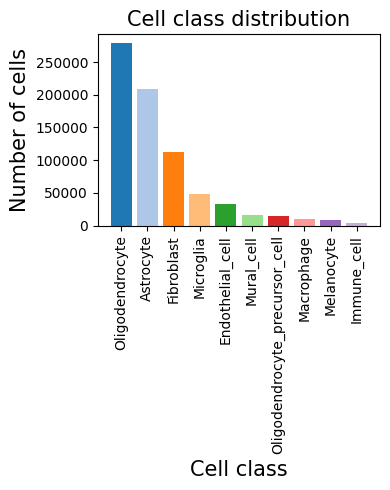

In [7]:
from matplotlib import cm
import matplotlib.pyplot as plt
sorted_classes = cell_counts.index.tolist()
categories=cell_counts.index
values = cell_counts
# Create the plot
fig=plt.figure(figsize=(4, 5))
colors = cm.get_cmap('tab20')(range(len(categories)))
plt.bar(categories, values, color=colors)

# Add titles and labels
plt.title('Cell class distribution',fontsize=15)
plt.xlabel('Cell class',fontsize=15)
plt.ylabel('Number of cells',fontsize=15)
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
#plt.show()

plt.savefig(f"{outdir}/figures/{bname}_celltype_bar_plot1.pdf", format='pdf', bbox_inches='tight')

In [8]:
f"{outdir}/figures/{bname}_celltype_bar_plot1.pdf"

'/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/clean/figures/major_hvg10000_epochnone_seurat_rs_1_subclass_sb_seurat_rmRPE_rmUnk_clean_celltype_bar_plot1.pdf'

In [10]:
import scanpy as sc
outdir="/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/clean"
bname="major_hvg10000_epochnone_seurat_rs_1_subclass_sb_seurat_rmRPE_rmUnk"
bname=f"{bname}_clean"
adata=sc.read(f"{outdir}/{bname}.h5ad")

/tmp/ipykernel_61421/1696849547.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


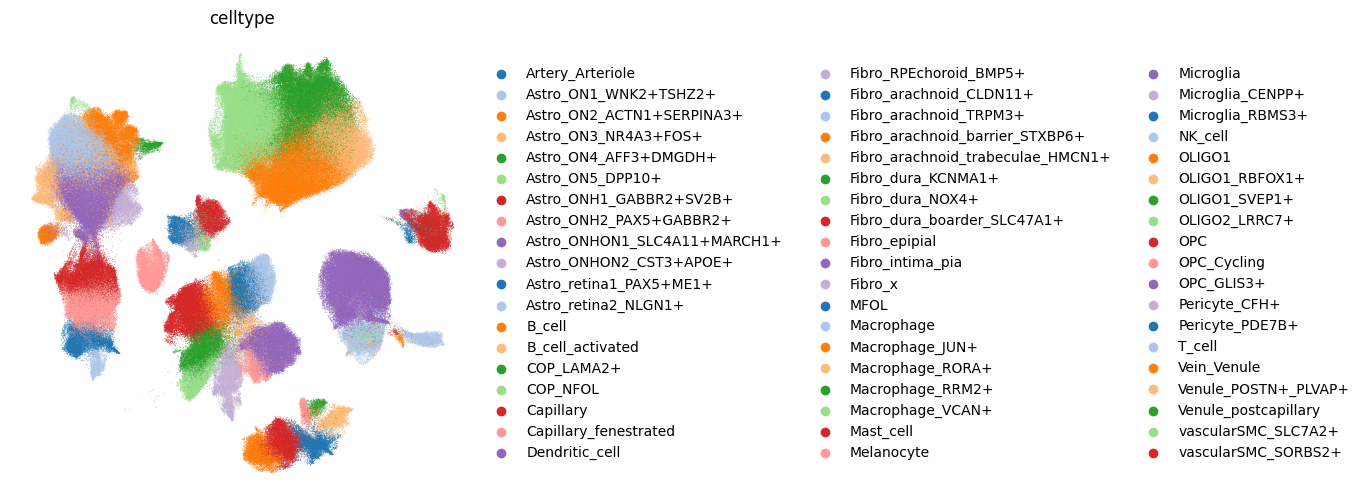

In [11]:
from matplotlib import cm
import matplotlib.pyplot as plt
#from matplotlib import rcParams
sc.settings.figdir="/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/major/clean/figures/"
plt.rcParams["figure.figsize"] = (6,6)
from matplotlib.colors import to_hex
#colors = cm.get_cmap('tab20')(range(len(categories)))
#colors = cm.get_cmap('tab20')(range(len(categories)))
cmap = cm.get_cmap('tab20')
colors = [to_hex(cmap(i)) for i in range(len(categories))]
sc.pl.umap(adata,color="celltype",save=f"_{bname}_umap_celltype.png", frameon=False, palette=colors,  size=1)

/tmp/ipykernel_61421/570035494.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["study"]=adata.obs["source"].replace(dt)


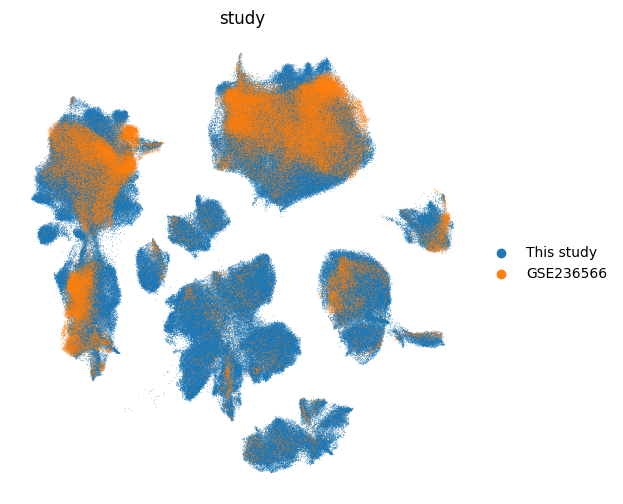

In [13]:
dt={"Chen": "This study", "Sanes": "GSE236566"}
adata.obs["study"]=adata.obs["source"].replace(dt)
sc.pl.umap(adata,color="study",save=f"_{bname}_umap_datasource.png", frameon=False,   size=1)

In [14]:
adata.obs["majorclass"]=adata.obs["majorclass1"]

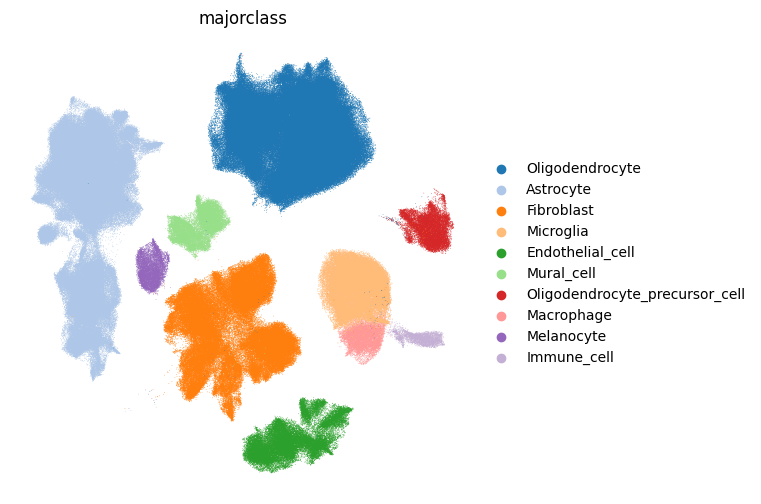

In [17]:
cell_counts = adata.obs['majorclass'].value_counts()

# 2. Get the sorted categories (most to least frequent)
sorted_classes = cell_counts.index.tolist()
categories=cell_counts.index
# 3. Reorder the categorical
adata.obs['majorclass'] = pd.Categorical(
    adata.obs['majorclass'],
    categories=sorted_classes,
    ordered=True
)

sc.pl.umap(adata,color="majorclass",palette=colors, save=f"_{bname}_umap_majorclass.png", frameon=False,   size=1)

In [ ]:
import scanpy as sc
opc=sc.read("/dfs3b/ruic20_lab/junw42/HCA_ON/data/5_refine_major/scvi/Oligodendrocyte_precursor_cell/clean/Oligodendrocyte_precursor_cell_subclass_seurat_cycling_rmRPE.h5ad")